In [32]:
#SET UP CELL
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import re
import warnings

from xgboost import XGBClassifier

os.environ["SCIPY_ARRAY_API"] = "1"

from inmoose.pycombat import pycombat_norm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from boruta import BorutaPy
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    accuracy_score,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.decomposition import PCA

In [4]:
os.environ["SCIPY_ARRAY_API"] = "1"


In [5]:
DATA_DIR = r'C:\Users\arjun\Downloads\pd glassbox biomarkers\data'

X_raw_log = pd.read_csv(f'{DATA_DIR}/processed/clean_normalized_counts.csv', index_col=0)
y_full_labels = np.loadtxt(f'{DATA_DIR}/processed/final_aligned_labels.csv', delimiter=',')



In [6]:
idx = X_raw_log.index.tolist()
is_2022_pattern = np.array([bool(re.match(r'^\d+_IonXpressRNA', s)) for s in idx])

In [7]:
assert is_2022_pattern.any(), "No 2022-pattern samples found -- check your index format."
positions_2022 = np.where(is_2022_pattern)[0]
assert set(positions_2022) == set(range(positions_2022.min(), positions_2022.max() + 1)), \
    "2022-pattern samples are not contiguous -- note to user do not use positional batch assignment!"

In [8]:
block_start, block_end = positions_2022.min(), positions_2022.max()
n_2020 = block_start
n_2023 = len(idx) - block_end - 1
batches_array = np.array(['2020'] * n_2020 + ['2022'] * len(positions_2022) + ['2023'] * n_2023)

In [9]:
assert len(batches_array) == len(X_raw_log), "Batch array length mismatch -- DO NOT proceed."
print(f"Batch counts -> 2020: {n_2020}, 2022: {len(positions_2022)}, 2023: {n_2023}")

Batch counts -> 2020: 100, 2022: 120, 2023: 100


In [10]:
X_train_raw, X_test_raw, y_train, y_test, batch_train, batch_test = train_test_split(
    X_raw_log, y_full_labels, batches_array,
    test_size=0.2, stratify=y_full_labels, random_state=42
)

const_filter = VarianceThreshold(threshold=0.0)
const_filter.fit(X_train_raw)

X_train_nconst = X_train_raw.loc[:, const_filter.get_support()]
X_test_nconst = X_test_raw.loc[:, const_filter.get_support()]

In [11]:
X_train_corrected_arr = pycombat_norm(
    counts = X_train_nconst.T,
    batch = list(batch_train)
)
X_train_corrected = pd.DataFrame(
    X_train_corrected_arr,
    index = X_train_nconst.columns,
    columns = X_train_nconst.index
).T

In [12]:
train_offset = X_train_corrected.mean(axis=0) - X_train_nconst.mean(axis=0)
X_test_corrected = X_test_nconst + train_offset

print(f"Train corrected: {X_train_corrected.shape}")
print(f"Test  corrected: {X_test_corrected.shape}")
print("ComBat applied")

Train corrected: (256, 2499)
Test  corrected: (64, 2499)
ComBat applied


In [13]:
low_var_filter = VarianceThreshold(threshold=0.0001)

X_train_filtered = pd.DataFrame(
    low_var_filter.fit_transform(X_train_corrected),
    index=X_train_corrected.index,
    columns=X_train_corrected.columns[low_var_filter.get_support()]
)
X_test_filtered = X_test_corrected[X_train_filtered.columns]

print(f"Train features after low-variance filtering: {X_train_filtered.shape[1]}")

# ── Standard Scaling (fit on TRAIN only, transform both) ─────────────
scaler = StandardScaler()
X_train_scaled_arr = scaler.fit_transform(X_train_filtered)
X_test_scaled_arr  = scaler.transform(X_test_filtered)

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=X_train_filtered.columns, index=X_train_filtered.index)
X_test_scaled  = pd.DataFrame(X_test_scaled_arr,  columns=X_test_filtered.columns,  index=X_test_filtered.index)

# Imputation fail-safe -- shouldn't trigger, but cheap insurance
if X_train_scaled.isna().any().any():
    X_train_scaled = X_train_scaled.fillna(0)
    X_test_scaled  = X_test_scaled.fillna(0)

print(f"Final matrix shape for Boruta: {X_train_scaled.shape}")
assert X_train_scaled.shape[0] == 256, "Sample count drifted -- check upstream chain."
assert X_test_scaled.shape[1] == X_train_scaled.shape[1], "Train/test feature mismatch."

Train features after low-variance filtering: 2427
Final matrix shape for Boruta: (256, 2427)


In [14]:
boruta_engine = RandomForestClassifier(
    n_estimators=200,        # explicit int — "auto" isn't valid for the base RF itself
    class_weight="balanced",
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

boruta_selector = BorutaPy(
    estimator=boruta_engine,
    n_estimators="auto",     # this is correct HERE — BorutaPy sizes trees itself per iteration
    verbose=2,
    max_iter=100,
    random_state=42
)

X_train_np = (
    X_train_scaled.values
    if hasattr(X_train_scaled, "values")
    else np.array(X_train_scaled)
)
y_train_np = y_train.values if hasattr(y_train, "values") else np.array(y_train)

print(f"Fitting Boruta on {X_train_np.shape[0]} samples × {X_train_np.shape[1]} features")
boruta_selector.fit(X_train_np, y_train_np)

Fitting Boruta on 256 samples × 2427 features
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	2427
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	2427
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	2427
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	2427
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	2427
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	2427
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	2427
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	204
Rejected: 	2223
Iteration: 	9 / 100
Confirmed: 	12
Tentative: 	192
Rejected: 	2223
Iteration: 	10 / 100
Confirmed: 	12
Tentative: 	192
Rejected: 	2223
Iteration: 	11 / 100
Confirmed: 	12
Tentative: 	192
Rejected: 	2223
Iteration: 	12 / 100
Confirmed: 	20
Tentative: 	134
Rejected: 	2273
Iteration: 	13 / 100
Confirmed: 	20
Tentative: 	134
Rejected: 	2273
Iteration: 	14 / 100
Confirmed: 	20
Tentative: 	134
Rejected: 	2273
Iteration: 	15 / 100
Confirmed: 	

,estimator,RandomForestC...0x2373422D740)
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M... 0x2373422D740
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",295


In [15]:
confirmed_mask = boruta_selector.support_
tentative_mask = boruta_selector.support_weak_

confirmed_features = X_train_scaled.columns[confirmed_mask].tolist()
tentative_features = X_train_scaled.columns[tentative_mask].tolist()

print(f"There are {len(confirmed_features)} confirmed features")
print(f"There are {len(tentative_features)} tentative features")

There are 63 confirmed features
There are 22 tentative features


In [16]:
X_train_selected = X_train_scaled[confirmed_features]
X_test_selected = X_test_scaled[confirmed_features]

print(X_train_selected.shape)
print(X_test_selected.shape)

(256, 63)
(64, 63)


In [17]:
assert X_train_selected.shape[1] == X_test_selected.shape[1]
assert X_train_selected.shape[1] > 0

In [18]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)

rf_param_grid = {
    'n_estimators': [200,300,500],
    'max_depth': [4,6,8],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf': [1,3,5],
    'max_features': ['sqrt','log2']
}

rf_grid_search = GridSearchCV(
    estimator = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [19]:
rf_grid_search.fit(X_train_selected, y_train)
print(f"best parameters: {rf_grid_search.best_params_}")
print(f"best auc: {rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
best auc: 0.9386


In [20]:
scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()
print(f"scale_pos_weight (neg/pos ratio): {scale_pos_weight:.3f}")

scale_pos_weight (neg/pos ratio): 2.325


In [21]:
xgb_param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.85],
    'colsample_bytree': [0.5, 0.7], 
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric = 'auc',
        random_state = 42,
        n_jobs = -1
    ),
    param_grid=xgb_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose = 1
)

In [22]:
xgb_grid_search.fit(X_train_selected, y_train)
print(f"best params with xgboost: {xgb_grid_search.best_params_}")
print(f"best CV AUC with xgboost: {xgb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
best params with xgboost: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
best CV AUC with xgboost: 0.9514


**Random Forest**  
best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}  
best auc: 0.9386  

**XGboost**  
best params with xgboost: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}  
best CV AUC with xgboost: 0.9514

In [23]:
#We're gonna compare the models and choose the best one. To avoid hardcoding one particular model I'm gonna use an if loop to decide
print(f"Random Forest CV AUC: {rf_grid_search.best_score_:.4f}")
print(f"XGboost CV AUC: {xgb_grid_search.best_score_:.4f}")
if rf_grid_search.best_score_ >= xgb_grid_search.best_score_:
    final_model = rf_grid_search.best_estimator_
    final_model_name = "Random Forest"
else:
    final_model = xgb_grid_search.best_estimator_
    final_model_name = "XGBoost" 
print(f"\nselected model: {final_model_name}") 
print(f"Hyperparameters: {final_model.get_params()}")  

Random Forest CV AUC: 0.9386
XGboost CV AUC: 0.9514

selected model: XGBoost
Hyperparameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'auc', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': np.float64(2.324675324675325), 'subsample': 0.7, 'tree_method': None, 'validate_param

In [24]:
oof_probabilities = cross_val_predict(
    final_model, X_train_selected, y_train,
    cv=cv_strategy, method='predict_proba', n_jobs=-1
)[:,1]

fpr_oof, tpr_oof, roc_thresh_oof = roc_curve(y_train, oof_probabilities)
youden_threshold = roc_thresh_oof[np.argmax(tpr_oof - fpr_oof)]

In [25]:
precisions_oof, recalls_oof, pr_thresh_oof = precision_recall_curve(y_train, oof_probabilities)
beta = 2
f2_scores_oof = ((1 + beta**2) * precisions_oof * recalls_oof) / (beta**2 * precisions_oof + recalls_oof + 1e-8)
f2_threshold = pr_thresh_oof[np.argmax(f2_scores_oof[:-1])]

print(f"Youden's J Threshold (from CV): {youden_threshold:.4f}")
print(f"F2-Optimal Threshold (from CV): {f2_threshold:.4f}")


Youden's J Threshold (from CV): 0.0932
F2-Optimal Threshold (from CV): 0.0932


In [26]:
operating_threshold = f2_threshold
print(f"\nOperating threshold locked in: {operating_threshold:.4f}")


Operating threshold locked in: 0.0932


In [27]:
y_test_clean = np.array(y_test).ravel()
final_probabilities = final_model.predict_proba(X_test_selected)[:,1]
y_pred_operating = (final_probabilities >= operating_threshold).astype(int)

In [28]:
official_auc = roc_auc_score(y_test_clean, final_probabilities)
official_ap = average_precision_score(y_test_clean, final_probabilities)

In [29]:
#stats
print(f"model: {final_model_name}")
print(f"test AUC: {official_auc:.4f}")
print(f"test average precision: {official_ap:.4f}")
print(f"operating threshold: {operating_threshold:.4f}")
print()
print(classification_report(y_test_clean, y_pred_operating, target_names=["Control", "PD"]))
print(confusion_matrix(y_test_clean, y_pred_operating))

model: XGBoost
test AUC: 0.7614
test average precision: 0.6243
operating threshold: 0.0932

              precision    recall  f1-score   support

     Control       0.82      0.40      0.54        45
          PD       0.36      0.79      0.49        19

    accuracy                           0.52        64
   macro avg       0.59      0.59      0.51        64
weighted avg       0.68      0.52      0.52        64

[[18 27]
 [ 4 15]]


Let's try using Logistic regression

In [33]:
logreg_model = LogisticRegressionCV(
    Cs=10,
    cv=StratifiedKFold(5,shuffle=True, random_state=42),
    penalty="l1",
    solver='liblinear',
    scoring='roc_auc',
    max_iter=5000,
    random_state=42, 
    class_weight='balanced'
)
logreg_model.fit(X_train_scaled, y_train)
selected_mask = logreg_model.coef_[0] != 0

In [34]:
selected_mirnas = X_train_scaled.columns[selected_mask].tolist()
print(f"best c: {logreg_model.C_[0]:.4f}")
print(f"nonzero coefficients(selected mirnas): {len(selected_mirnas)}")

best c: 0.0464
nonzero coefficients(selected mirnas): 14


In [35]:
logreg_probs = logreg_model.predict_proba(X_test_scaled[X_train_scaled.columns])[:, 1]
logreg_auc = roc_auc_score(y_test, logreg_probs)
print(f"test auc: {logreg_auc:.4f}")#jackpot we're using logistic regression then

test auc: 0.8211


In [36]:
coef_df = pd.DataFrame({
    'miRNA': selected_mirnas,
    'coefficient': logreg_model.coef_[0][selected_mask]
}).sort_values('coefficient', key=abs, ascending=False).reset_index(drop=True)

print(coef_df.to_string(index=False))
print(f"\n{(coef_df['coefficient'] > 0).sum()} upregulated in PD, {(coef_df['coefficient'] < 0).sum()} downregulated")

                       miRNA  coefficient
   hsa-mir-1290_hsa-miR-1290    -0.255068
    hsa-let-7b_hsa-let-7b-5p     0.234288
hsa-mir-130b_hsa-miR-130b-3p    -0.092375
  hsa-mir-15a_hsa-miR-15a-5p     0.076690
  hsa-mir-195_hsa-miR-195-5p    -0.058720
   hsa-mir-1323_hsa-miR-1323     0.051309
  hsa-mir-887_hsa-miR-887-3p    -0.041863
   hsa-mir-3960_hsa-miR-3960    -0.038912
  hsa-mir-197_hsa-miR-197-5p    -0.020608
hsa-mir-1306_hsa-miR-1306-5p    -0.017021
   hsa-mir-8072_hsa-miR-8072    -0.011562
  hsa-mir-522_hsa-miR-522-3p     0.007622
hsa-mir-526b_hsa-miR-526b-5p     0.005669
hsa-mir-6743_hsa-miR-6743-3p    -0.005317

5 upregulated in PD, 9 downregulated


In [37]:
locked_logreg = LogisticRegression(
    C = logreg_model.C_[0], penalty='l1', solver='liblinear',
    class_weight='balanced', random_state=42, max_iter=5000
)
oof_probs_logreg = cross_val_predict(
    locked_logreg, X_train_scaled, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    method = 'predict_proba', n_jobs=-1
)[:,1]

In [38]:
precisions_lr, recalls_lr, pr_thresh_lr = precision_recall_curve(y_train, oof_probs_logreg)
f2_lr = ((1 + 4) * precisions_lr * recalls_lr) / (4 * precisions_lr + recalls_lr + 1e-8)
logreg_threshold = pr_thresh_lr[np.argmax(f2_lr[:-1])]
print(f"f2 checked threshold: {logreg_threshold:.4f}")

f2 checked threshold: 0.4425


In [39]:
#REAL final stats
 
y_pred_logreg = (logreg_probs >= logreg_threshold).astype(int)

print(f"test auc: {logreg_auc:.4f}")
print(f"threshold we're using: {logreg_threshold:.4f}")
print()
print(classification_report(y_test, y_pred_logreg, target_names = ["Control", "PD"]))
print(confusion_matrix(y_test, y_pred_logreg))

test auc: 0.8211
threshold we're using: 0.4425

              precision    recall  f1-score   support

     Control       0.96      0.51      0.67        45
          PD       0.45      0.95      0.61        19

    accuracy                           0.64        64
   macro avg       0.70      0.73      0.64        64
weighted avg       0.81      0.64      0.65        64

[[23 22]
 [ 1 18]]


**FINAL SHAP PLOT**

Background dataset has 256 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=256 when initializing the masker.


                       miRNA  mean_abs_shap  coefficient
   hsa-mir-1290_hsa-miR-1290       0.279811    -0.255068
    hsa-let-7b_hsa-let-7b-5p       0.173614     0.234288
  hsa-mir-195_hsa-miR-195-5p       0.152723    -0.058720
hsa-mir-130b_hsa-miR-130b-3p       0.071780    -0.092375
  hsa-mir-15a_hsa-miR-15a-5p       0.053783     0.076690
   hsa-mir-3960_hsa-miR-3960       0.038623    -0.038912
   hsa-mir-1323_hsa-miR-1323       0.037530     0.051309
  hsa-mir-887_hsa-miR-887-3p       0.033148    -0.041863
hsa-mir-1306_hsa-miR-1306-5p       0.017251    -0.017021
  hsa-mir-197_hsa-miR-197-5p       0.010976    -0.020608
   hsa-mir-8072_hsa-miR-8072       0.007468    -0.011562
hsa-mir-6743_hsa-miR-6743-3p       0.004798    -0.005317
  hsa-mir-522_hsa-miR-522-3p       0.004545     0.007622
hsa-mir-526b_hsa-miR-526b-5p       0.003173     0.005669


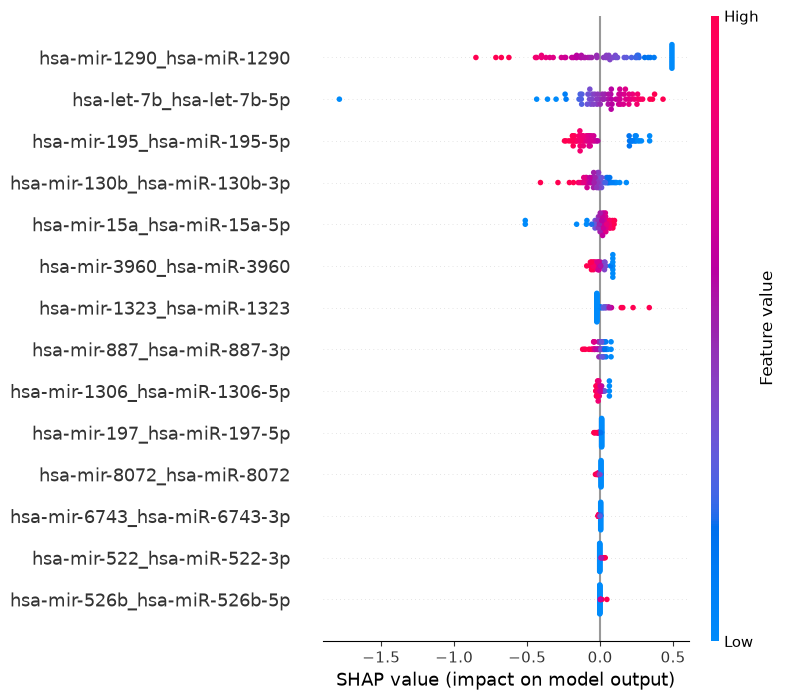

In [40]:
shap_model = LogisticRegression()
shap_model.coef_ = logreg_model.coef_[:, selected_mask]      # shape (1, 14)
shap_model.intercept_ = logreg_model.intercept_
shap_model.classes_ = logreg_model.classes_

explainer = shap.LinearExplainer(shap_model, X_train_scaled[selected_mirnas])
shap_values_lr = explainer.shap_values(X_test_scaled[selected_mirnas])

mean_abs_shap_lr = np.abs(shap_values_lr).mean(axis=0)
shap_ranking_lr = pd.DataFrame({
    'miRNA': selected_mirnas,
    'mean_abs_shap': mean_abs_shap_lr,
    'coefficient': logreg_model.coef_[0][selected_mask]
}).sort_values('mean_abs_shap', ascending=False)

print(shap_ranking_lr.to_string(index=False))
shap.summary_plot(shap_values_lr, X_test_scaled[selected_mirnas], plot_type='dot')

We made the model and have the shap values, now we need to make poster plots.

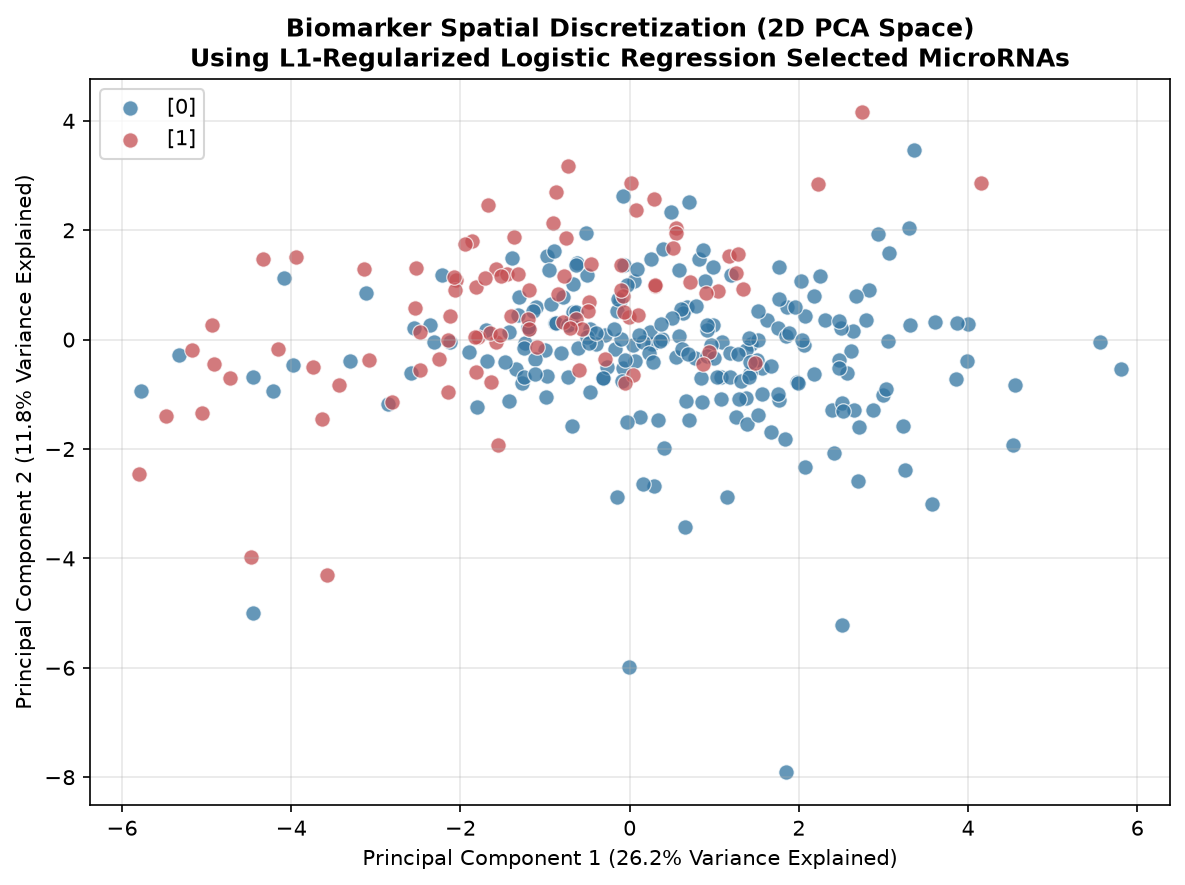

In [41]:
#pca biomarker space plot
X_all_pca_input = pd.concat([X_train_scaled[selected_mirnas], X_test_scaled[selected_mirnas]])
y_all = np.concatenate([y_train, y_test])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_pca_input)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
colors, labels = {0: '#3274A1', 1: '#C44E52'}, {0: 'Healthy Control', 1: "Parkinson's Disease"}
for cls in [0, 1]:
    mask = y_all == cls
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[cls], label=[cls],
        alpha=0.75, s=55, edgecolors='white', linewidths=0.6)

ax.set_xlabel(f"Principal Component 1 ({var_exp[0]:.1f}% Variance Explained)")
ax.set_ylabel(f"Principal Component 2 ({var_exp[1]:.1f}% Variance Explained)")
ax.set_title('Biomarker Spatial Discretization (2D PCA Space)\nUsing L1-Regularized Logistic Regression Selected MicroRNAs', fontweight='bold')#fancy title
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_biomarker_space.png', dpi=150, bbox_inches = 'tight')
plt.show()